In [2]:
%load_ext autoreload
%autoreload 2

# FGFR4 data preparation

In [1]:
import os,sys
os.environ.setdefault('BOLTZ_CACHE','~/projects/boltz') # change boltz cache path
from pymol import cmd
import pandas as pd
from detect_pocket import get_pocket_info_from_pdb_info, clean_structure

cmd.reinitialize()
cmd.fetch('4xcu',name='4xcu',type='cif',path='data/PDB')
clean_structure('4xcu','40M','A','A')
seq_boltz,pocket=get_pocket_info_from_pdb_info('4xcu','40M','A','A',radius=4)

In [11]:
!mkdir -p data/fgfr4
from util import get_a3m
get_a3m(seq_boltz,'data/fgfr4/fgfr4')
!cp data/MSA/crbn.a3m data/fgfr4/crbn.a3m
!cp data/MSA/vhl.a3m data/fgfr4/vhl.a3m

In [2]:
from util import update_uniprot_ptm_info,update_uniprot_uid2seq,idxmap_boltz2uniprot
df_resi2evidence=update_uniprot_ptm_info('P22455')
df_uid2seq=update_uniprot_uid2seq(['P22455'])
df_uid2seq=df_uid2seq[df_uid2seq['UniprotID']=='P22455']
seq_uniprot=df_uid2seq['seq'].iloc[0]
idxmap=idxmap_boltz2uniprot(seq_boltz,seq_uniprot)

/home/regen/ana/envs/boltz/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# FGFR4 agent training

Run these commands in your shell will be better.

In [ ]:
# !reinvent -l fgfr4_vhl.log -s 0 boltz_fgfr4_vhl.toml  
# !reinvent -l fgfr4_crbn.log -s 0 boltz_fgfr4_crbn.toml

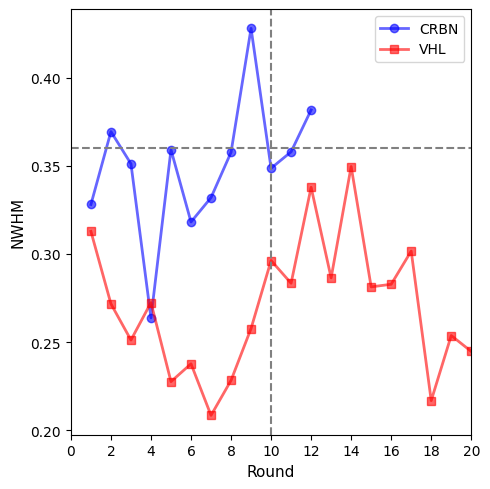

In [11]:
import pandas as pd
import numpy as np
fgfr_crbn_df=pd.read_csv('fgfr4_crbn_learning_1.csv',header='infer')
fgfr_vhl_df=pd.read_csv('fgfr4_vhl_learning_1.csv',header='infer')
fgfr_crbn_df['docking with boltz'] = fgfr_crbn_df['docking with boltz'].replace(-np.inf, np.nan)
fgfr_vhl_df['docking with boltz'] = fgfr_vhl_df['docking with boltz'].replace(-np.inf, np.nan)
crbn_means=fgfr_crbn_df.groupby('step')['docking with boltz'].mean()
vhl_means=fgfr_vhl_df.groupby('step')['docking with boltz'].mean()
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.plot(crbn_means.index, crbn_means.values, marker='o', label='CRBN', linewidth=2,color='blue',alpha=0.6)
plt.plot(vhl_means.index, vhl_means.values, marker='s', label='VHL', linewidth=2,color='red',alpha=0.6)
plt.axhline(y=0.36, color='gray', linestyle='--', linewidth=1.5)
plt.axvline(x=10, color='gray', linestyle='--', linewidth=1.5)
plt.xlabel('Round', fontsize=11)
plt.ylabel('NWHM', fontsize=11)
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 2,dtype=int))
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig('pics/rl.png',dpi=600)
plt.show()

## Sampling and clustering FGFR4 candidates 

Use sample mode of REINVENT to find a couple of promising linkers. Cluster them to find a series of compounds.

Can be fast enough, even on cpu.

Seed for sample mode does not actually work right now. 

In [ ]:
# !reinvent -s 0 -l boltz_fgfr4_crbn_sample.log boltz_fgfr4_crbn_sample.toml

In [29]:
import pandas as pd
from rdkit.Chem import rdRascalMCES,MolFromSmiles
fgfr_crbn_samples=pd.read_csv('boltz_fgfr_crbn_sampling.csv',header='infer')
fgfr_crbn_samples['Linker']=fgfr_crbn_samples['Linker'].str.replace('[*]','[Po]',1).str.replace('[*]','[Es]',1) # mark the start and end connect points
fgfr_crbn_samples['mol']=fgfr_crbn_samples['Linker'].apply(MolFromSmiles)
cluster_mols=rdRascalMCES.RascalCluster(fgfr_crbn_samples['mol'])

In [30]:
fgfr_crbn_samples['cluster'] = -1
for cluster_id, cluster_indices in enumerate(cluster_mols):
    for idx in cluster_indices:
        fgfr_crbn_samples.loc[idx, 'cluster'] = cluster_id
fgfr_crbn_samples.sort_values(['cluster','NLL']).to_csv('boltz_fgfr_crbn_sampling_clustered.csv',index=False,columns=[c for c in fgfr_crbn_samples.columns if c!='mol'])
fgfr_crbn_samples.groupby('cluster')['NLL'].mean()

cluster
0     11.843115
1      8.815250
2     13.102000
3      7.292500
4     13.726667
5      6.457500
6      8.650000
7     13.865000
8     13.540000
9     11.105000
10    13.675000
11    18.661111
Name: NLL, dtype: float64

In [27]:
fgfr_crbn_samples['NLL_mean'] = fgfr_crbn_samples.groupby('cluster')['NLL'].transform('mean')
fgfr_crbn_samples.sort_values('NLL').drop_duplicates('cluster',keep='first').sort_values('NLL_mean').to_csv('boltz_fgfr_crbn_sampling_clustered_top.csv',index=False)

In [31]:
!mkdir -p pics/fgfr4_linker
from rdkit import Chem
from rdkit.Chem import Draw
for idx,linker in enumerate(fgfr_crbn_samples['Linker'],2):
    mol = Chem.MolFromSmiles(linker)
    if mol is not None:
        img = Draw.MolToImage(mol, size=(300, 300))
        img.save(f'pics/fgfr4_linker/{idx}.png')
    else:
        print(f"Warning: Invalid SMILES at index {idx}: {linker}")

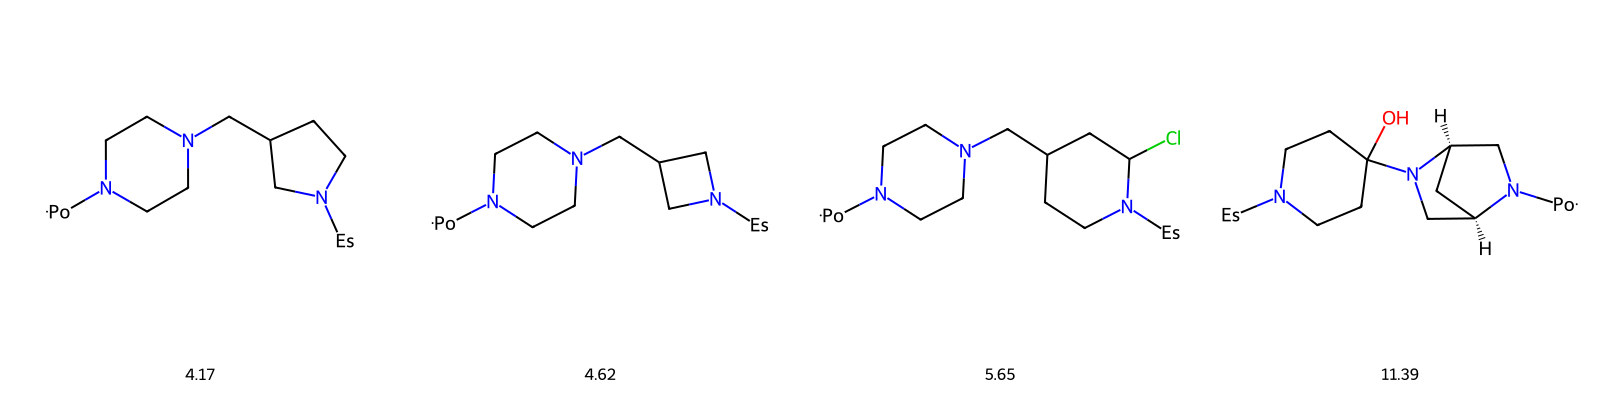

In [33]:
from rdkit.Chem import Draw
cluster3=fgfr_crbn_samples[fgfr_crbn_samples['cluster']==3].sort_values('NLL')
cluster5=fgfr_crbn_samples[fgfr_crbn_samples['cluster']==5].sort_values('NLL')
cluster6=fgfr_crbn_samples[fgfr_crbn_samples['cluster']==6].sort_values('NLL')
cluster1=fgfr_crbn_samples[fgfr_crbn_samples['cluster']==1].sort_values('NLL')
def draw_cluster_mols(df):
    mols = df['mol'].tolist()
    legends = df['NLL'].astype('str').tolist() 
    img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(400, 400), legends=legends)
    display(img)
draw_cluster_mols(cluster5)

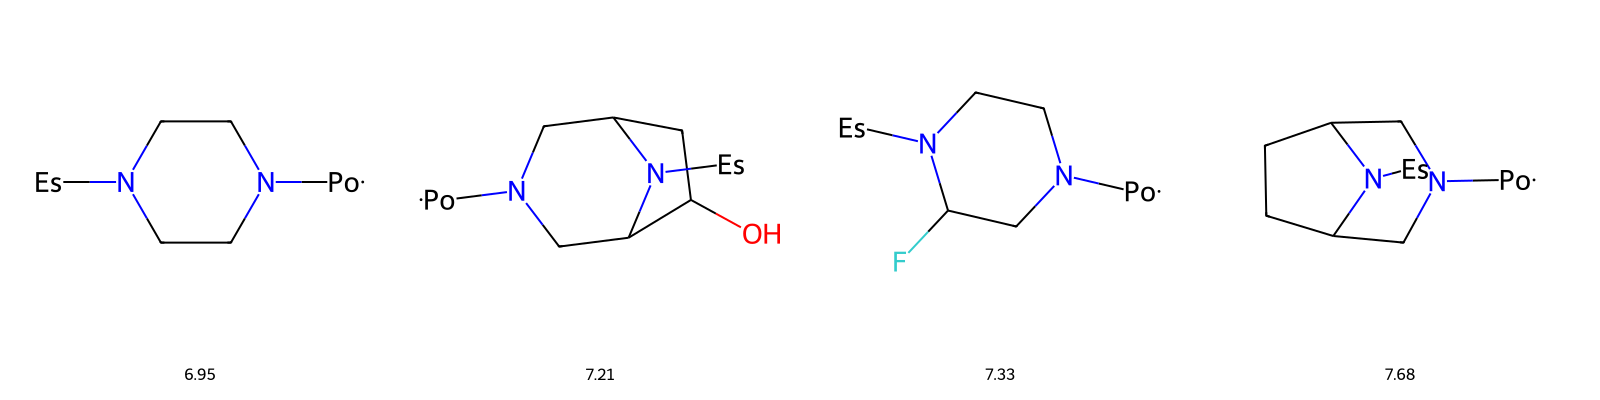

In [34]:
draw_cluster_mols(cluster3)

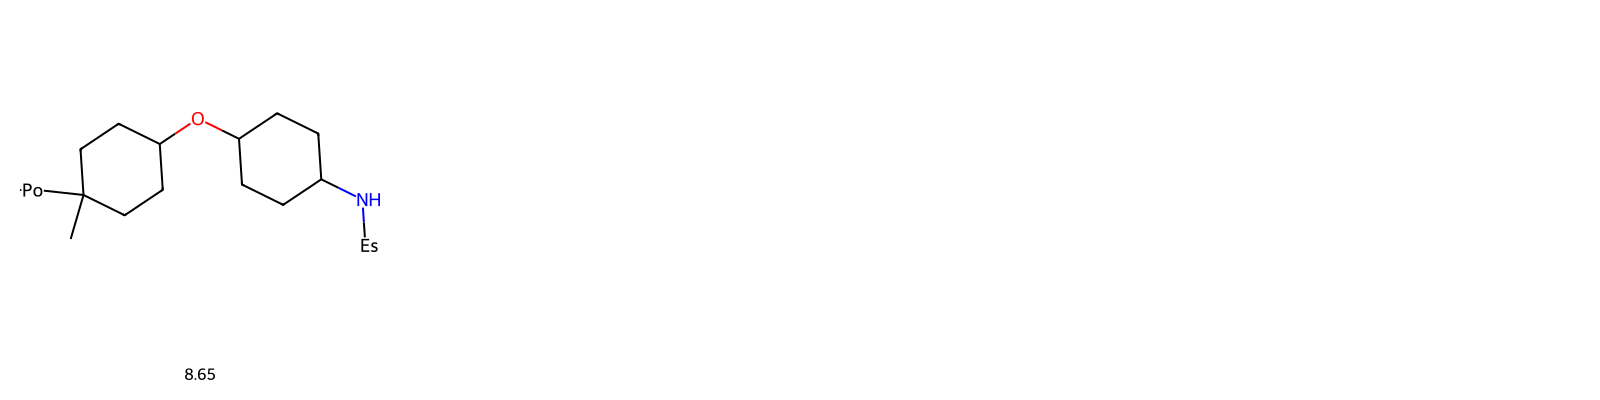

In [35]:
draw_cluster_mols(cluster6)

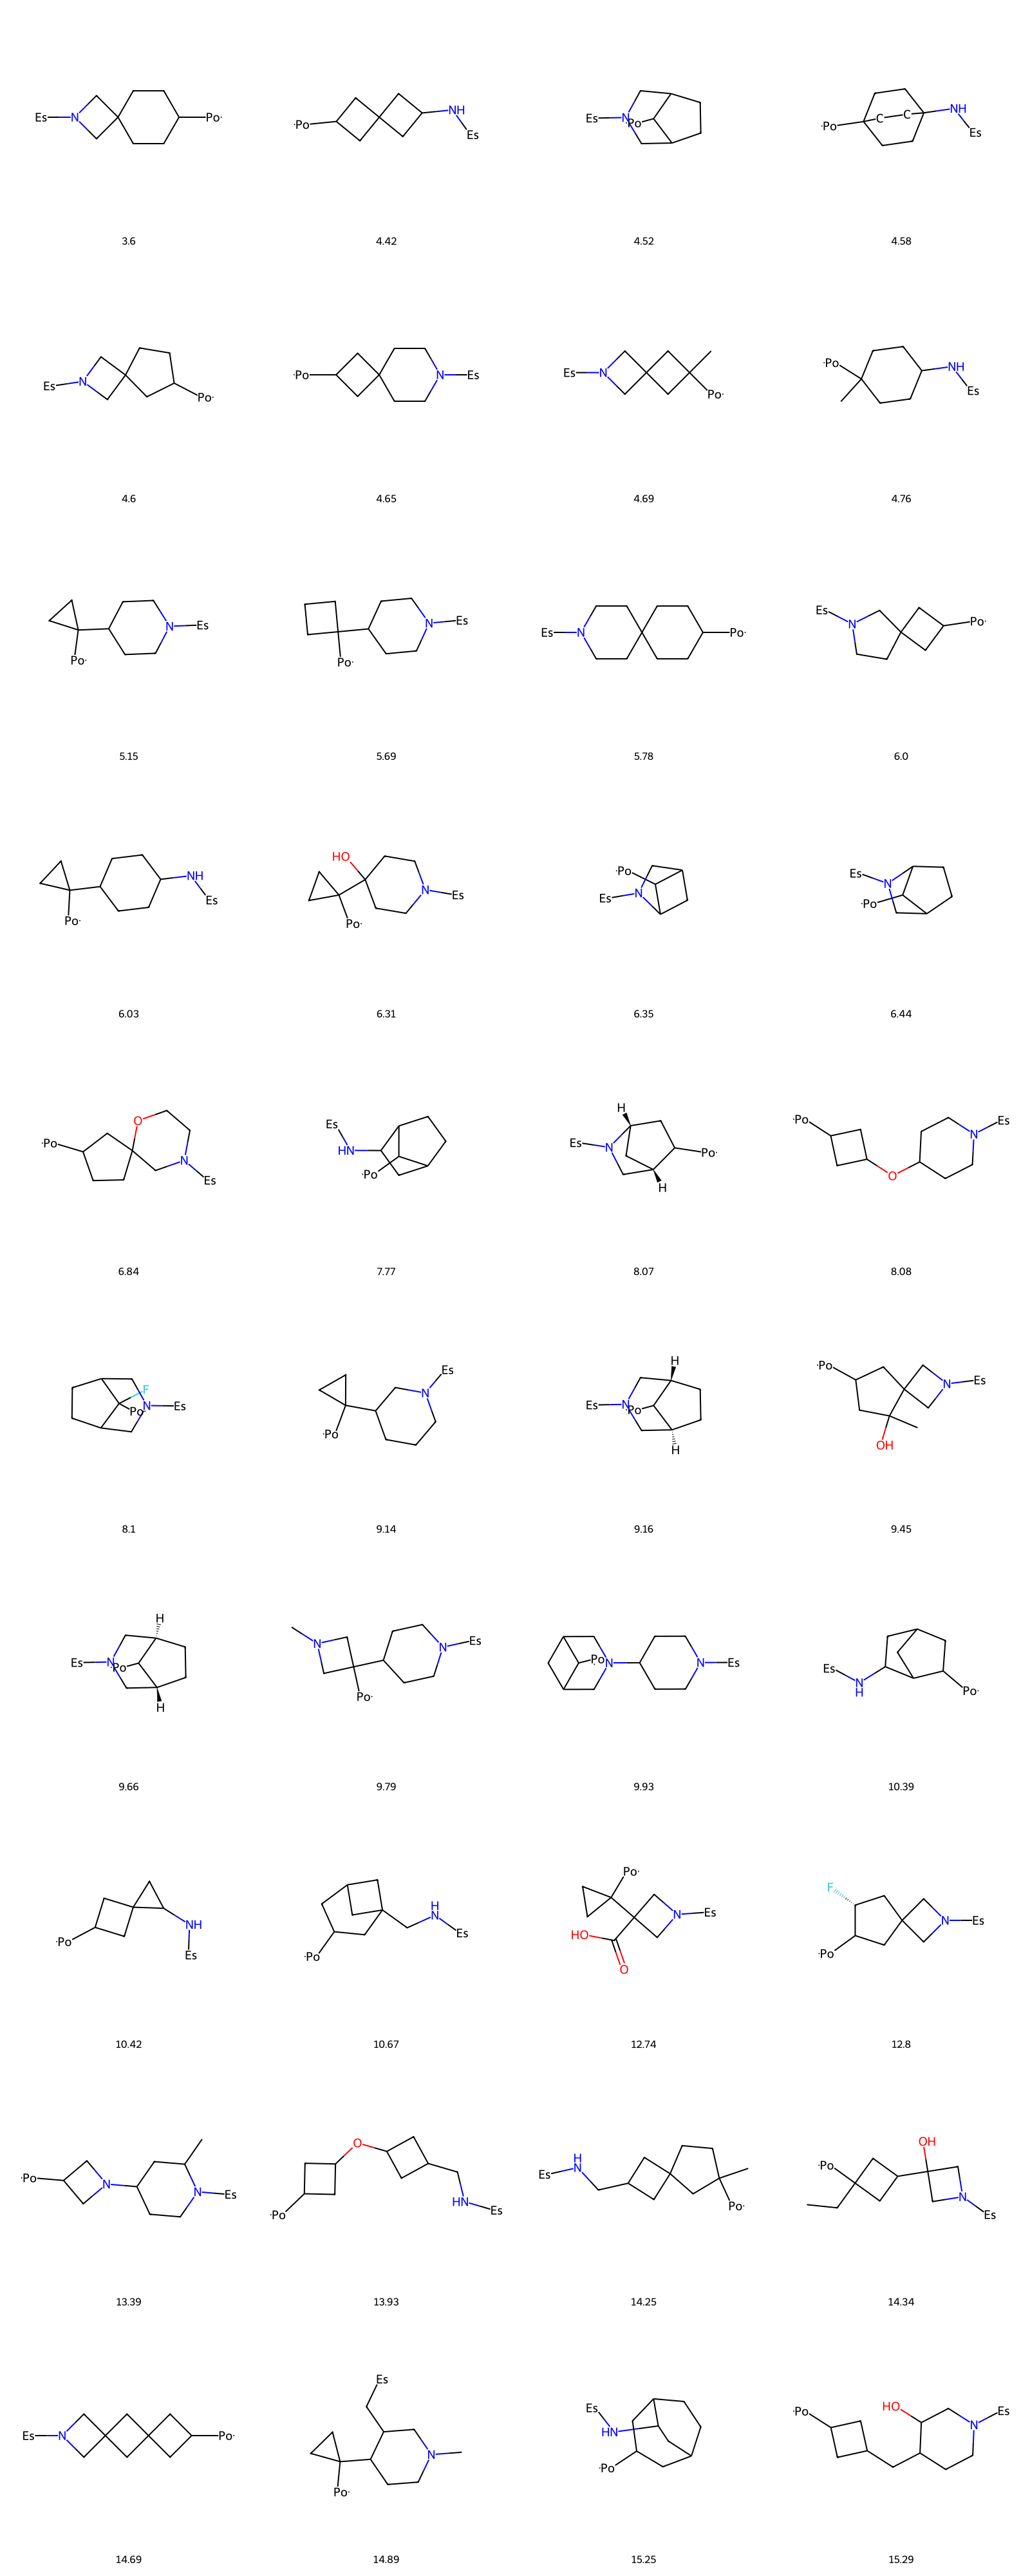

In [36]:
draw_cluster_mols(cluster1)

## Calculate D11, the best candidate

In [3]:
from reinvent_plugins.components.comp_boltz_fgfr4 import calculate_one_affinity_score
smi_d11='CCC(=O)Nc1cc(cc(c1Nc1ncc2c(n1)ccc(c2)c1c(Cl)c(OC)cc(c1Cl)OC)C)N1CCN(CC1)CC1CCN(CC1)c1cccc2c1C(=O)N(C2=O)C1CCC(=O)NC1=O'
sc_items=calculate_one_affinity_score(smi_d11,'fgfr4',seq_boltz,pocket,'crbn',output_path='data/fgfr4',msa_path='data/fgfr4',is_covalent_poi=True,extract_from_precomputed=False)
sc_items

(0.4831730385955738,
 {'lgKd_ternary': -4.1220502853393555,
  'dist_ub_square': 126.36874705804894,
  'dist_ub': 11.241385459899902,
  'num_clash': 8,
  'ref_model': 'model3_clean.pdb',
  'closest_lys_resid': 150})

In [5]:
!grep -A 1 "bond" data/fgfr4/fgfr4_crbn_AMZUZKXFLXHAHI-UHFFFAOYSA-N_ternary.yaml

  - bond:
      atom1: [L, 1, C104]


In [5]:
from util import cif_boltz2uniprot
best_cif='data/fgfr4/fgfr4_crbn_AMZUZKXFLXHAHI-UHFFFAOYSA-N_ternary_best.cif'
cif_boltz2uniprot(best_cif,seq_boltz,seq_uniprot)

In [5]:
lys_id=idxmap[int(sc_items[1]['closest_lys_resid'])]
print('Closest lys near to Ub-Gly is',lys_id)

Closest lys near to Ub-Gly is 607


In [9]:
print('The evidence score of Lys',lys_id,'is',df_resi2evidence[df_resi2evidence['uniprot_lys_resid']==lys_id]['evidence_score'].iloc[0])

The evidence score of Lys 607 is 0


In [6]:
from util import generate_pymol_pse
generate_pymol_pse(best_cif[:-4]+'_uni.cif',607,'data/PDB/clean/4xcu_ref.cif',ref_cif_e3='data/PDB/clean/8rqa_ref.cif',covalent_resid=552,covalent_res_atomname='SG',covalent_lig_atomname='C104')

In [ ]:
!pymol 'data/fgfr4/fgfr4_crbn_AMZUZKXFLXHAHI-UHFFFAOYSA-N_ternary_best_uni.pse'
# or open pse file directly in pymol

In [4]:
smidict={'C1':'N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1C)C(=O)[C@H](C(C)(C)C)NC(=O)CCC(=O)N1CCN(CC1)c1cc(c(c(c1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl)NC(=O)CC',
'C2':'N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1C)C(=O)[C@H](C(C)(C)C)NC(=O)CCCCC(=O)N1CCN(CC1)c1cc(c(c(c1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl)NC(=O)CC',
'C3':'N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1C)C(=O)[C@H](C(C)(C)C)NC(=O)CCCCCCC(=O)N1CCN(CC1)c1cc(c(c(c1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl)NC(=O)CC',
'C4':'N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1C)C(=O)[C@H](C(C)(C)C)NC(=O)CCOCCC(=O)N1CCN(CC1)c1cc(c(c(c1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl)NC(=O)CC',
'C5':'N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1C)C(=O)[C@H](C(C)(C)C)NC(=O)CCOCCOCCC(=O)N1CCN(CC1)c1cc(c(c(c1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl)NC(=O)CC',
'C6':'N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1C)C(=O)[C@@H](NC(=O)CCOCCOCCOCCOCCC(=O)N1CCN(CC1)c1cc(c(c(c1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl)NC(=O)CC)C(C)(C)C',
'D1':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)c1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D2':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCNc1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D3':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCCCNc1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D4':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCCCCCNc1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D5':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCCCCCCCNc1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D6':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCCCCCCCCCNc1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D7':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCOCCNc1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D8':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCOCCOCCNc1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D9':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCOCCOCCOCCOCCNc1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D10':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCOCCOCCOCCOCCOCCOCCNc1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D11':'CCC(=O)Nc1cc(cc(c1Nc1ncc2c(n1)ccc(c2)c1c(Cl)c(OC)cc(c1Cl)OC)C)N1CCN(CC1)CC1CCN(CC1)c1cccc2c1C(=O)N(C2=O)C1CCC(=O)NC1=O',
'D12':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)CC1CN(CC1)c1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',
'D13':'C(=O)(CC)Nc1c(c(cc(c1)N1CCN(CC1)CC1CN(C1)c1c2C(=O)N(C(=O)c2ccc1)C1C(=O)NC(=O)CC1)C)Nc1nc2c(cn1)cc(cc2)c1c(c(cc(c1Cl)OC)OC)Cl',}
# CYS added form smiles

fgfr4_c1_d13_results=[]
for name,smi in smidict.items():
    print(name,end='\t')
    if name.startswith('C'):
        e3='vhl'
    else:
        e3='crbn'
    record=calculate_one_affinity_score(smi,'fgfr4',seq_boltz,pocket,e3,output_path='data/fgfr4',msa_path='data/fgfr4',is_covalent_poi=True,extract_from_precomputed=False)
    print(record)
    fgfr4_c1_d13_results.append(record)

C1	(0.3270303153064821, {'lgKd_ternary': -4.542509078979492, 'dist_ub_square': 1805.7302658168046, 'dist_ub': 42.4938850402832, 'num_clash': 0, 'ref_model': 'model1_clean.pdb', 'closest_lys_resid': 83})
C2	(0.35268764037611905, {'lgKd_ternary': -4.550650596618652, 'dist_ub_square': 1674.8561870193953, 'dist_ub': 40.92500686645508, 'num_clash': 0, 'ref_model': 'model1_clean.pdb', 'closest_lys_resid': 83})
C3	(0.3153595279386802, {'lgKd_ternary': -4.961713790893555, 'dist_ub_square': 1866.8712838450447, 'dist_ub': 43.207305908203125, 'num_clash': 0, 'ref_model': 'model1_clean.pdb', 'closest_lys_resid': 83})
C4	(0.28100547859943426, {'lgKd_ternary': -4.307790756225586, 'dist_ub_square': 1969.1744805837516, 'dist_ub': 44.37538146972656, 'num_clash': 0, 'ref_model': 'model1_clean.pdb', 'closest_lys_resid': 83})
C5	(0.2069091714648364, {'lgKd_ternary': -4.276623725891113, 'dist_ub_square': 2246.751103829607, 'dist_ub': 47.399906158447266, 'num_clash': 0, 'ref_model': 'model1_clean.pdb', 'clo

In [5]:
import pandas as pd
si002=pd.read_csv('SI002Molecular formula strings.csv')
rows=[]
for name,record in zip(smidict,fgfr4_c1_d13_results):
    score,metrics=record 
    lys_id=idxmap[int(metrics['closest_lys_resid'])]
    rows.append({'Name':name,
                 'E3 Ligase':'vhl' if name.startswith('C') else 'crbn',
                 'NWHM':score,
                 'lgKd_ternary':metrics['lgKd_ternary'],
                 'dist_ub':metrics['dist_ub'],
                 'num_clash':int(metrics['num_clash']),
                 'ub_lys_site':int(lys_id)})
df_sc=pd.DataFrame(rows)
df_merged=pd.merge(si002,df_sc,on='Name',how='left')
df_merged['num_clash']=df_merged['num_clash'].astype('Int64')
df_merged['ub_lys_site']=df_merged['ub_lys_site'].astype('Int64')

df_merged.to_csv('SI002Molecular formula strings_NHWM.csv',index=False)
df_merged

,Name,SMILES,Hep3B cell IC50 (μM),FGFR4 DC50 (μM),E3 Ligase,NWHM,lgKd_ternary,dist_ub,num_clash,ub_lys_site
0,C1,N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1...,1.50±0.19,>1,vhl,0.327030,-4.542509,42.493885,0,531
1,C2,N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1...,2.64±0.08,>1,vhl,0.352688,-4.550651,40.925007,0,531
2,C3,N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1...,>3,>1,vhl,0.315360,-4.961714,43.207306,0,531
3,C4,N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1...,>3,>1,vhl,0.281005,-4.307791,44.375381,0,531
4,C5,N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1...,>3,>1,vhl,0.206909,-4.276624,47.399906,0,531
5,C6,N1([C@@H](C[C@H](C1)O)C(=O)NCc1ccc(cc1)c1scnc1...,>3,>1,vhl,0.145330,-3.750454,50.821121,0,531
6,D1,C(=O)(C=C)Nc1c(c(cc(c1)N1CCN(CC1)c1c2C(=O)N(C(...,0.526±0.01,0.452±0.01,crbn,0.412573,-4.116467,8.660686,25,512
7,D2,C(=O)(C=C)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCNc1c2C...,0.728±0.02,0.538±0.13,crbn,0.343435,-4.244569,6.619259,45,737
8,D3,C(=O)(C=C)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCCCNc1c...,0.283±0.01,0.176±0.02,crbn,0.454171,-4.189281,2.810982,28,745
9,D4,C(=O)(C=C)Nc1c(c(cc(c1)N1CCN(CC1)C(=O)CCCCCCNc...,0.964±0.02,0.957±0.12,crbn,0.350741,-3.867632,10.091748,25,745


R2 computed on 7 compounds with DC50 <= 1 uM; 12 compounds with DC50 > 1 uM truncated at 1 uM on the plot and excluded
linear regression of log(DC50) on NWHM: R2 = 0.764 (p = 0.010, slope = -7.67)
20000 paired bootstrap resamples, 95% percentile interval: R2 [0.34, 0.97]


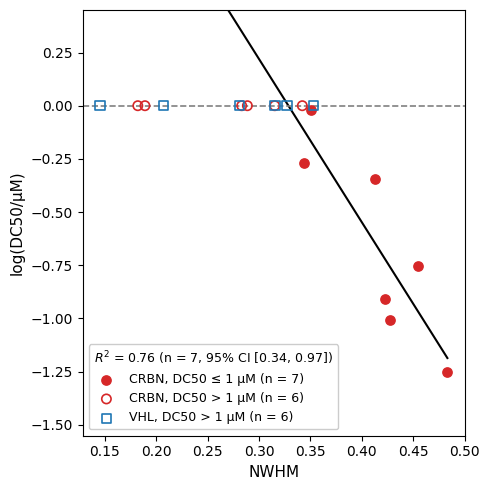

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

dc50_col='FGFR4 DC50 (μM)'
si_df=df_merged[df_merged['NWHM'].notna()].copy() # BLU554 has no NWHM prediction
dc50_text=si_df[dc50_col].astype(str)
si_df['DC50_uM']=dc50_text.str.extract(r'([0-9]*\.?[0-9]+)')[0].astype(float)
si_df['censored']=dc50_text.str.contains('>')
si_df['logDC50']=np.log10(si_df['DC50_uM'].clip(upper=1.0))

fit_df=si_df[~si_df['censored']]
nwhm=fit_df['NWHM'].to_numpy(dtype=float)
log_dc50=fit_df['logDC50'].to_numpy(dtype=float)
n_fit=len(nwhm)
regression=stats.linregress(nwhm,log_dc50)
r2=regression.rvalue**2


def percentile_interval(samples,alpha):
    samples=samples[np.isfinite(samples)]
    return np.percentile(samples,[100*alpha/2,100*(1-alpha/2)])


alpha=0.05
n_boot=20000
rng=np.random.default_rng(0)
boot_r2=np.full(n_boot,np.nan)
for i in range(n_boot):
    selection=rng.integers(0,n_fit,n_fit)
    x_boot,y_boot=nwhm[selection],log_dc50[selection]
    if np.ptp(x_boot)==0 or np.ptp(y_boot)==0:
        continue
    boot_r2[i]=stats.pearsonr(x_boot,y_boot).statistic**2
ci_r2=percentile_interval(boot_r2,alpha)

print(f'R2 computed on {n_fit} compounds with DC50 <= 1 uM; '
      f'{int(si_df["censored"].sum())} compounds with DC50 > 1 uM truncated at 1 uM on the plot and excluded')
print(f'linear regression of log(DC50) on NWHM: R2 = {r2:.3f} (p = {regression.pvalue:.3f}, slope = {regression.slope:.2f})')
print(f'{n_boot} paired bootstrap resamples, 95% percentile interval: R2 [{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]')

e3_style={'crbn':('CRBN','tab:red','o'),'vhl':('VHL','tab:blue','s')}
fig,ax=plt.subplots(figsize=(5,5))
for e3_key,(e3_name,color,marker) in e3_style.items():
    e3_df=si_df[si_df['E3 Ligase']==e3_key]
    measured=e3_df[~e3_df['censored']]
    censored=e3_df[e3_df['censored']]
    if len(measured):
        ax.scatter(measured['NWHM'],measured['logDC50'],s=45,color=color,marker=marker,zorder=3,
                   label=f'{e3_name}, DC50 ≤ 1 μM (n = {len(measured)})')
    if len(censored):
        ax.scatter(censored['NWHM'],np.zeros(len(censored)),s=45,facecolors='none',edgecolors=color,
                   marker=marker,linewidths=1.2,zorder=3,
                   label=f'{e3_name}, DC50 > 1 μM (n = {len(censored)})')
x_fit=np.linspace(si_df['NWHM'].min(),si_df['NWHM'].max(),50)
ax.plot(x_fit,regression.intercept+regression.slope*x_fit,color='black',linewidth=1.5,zorder=2)
ax.axhline(0,color='gray',linestyle='--',linewidth=1.2)
ax.set_ylim(fit_df['logDC50'].min()-0.3,0.45)
ax.set_xlabel('NWHM',fontsize=11)
ax.set_ylabel('log(DC50/μM)',fontsize=11)

ax.legend(fontsize=9,loc='lower left',framealpha=1,facecolor='white',alignment='left',
          title=f'$R^2$ = {r2:.2f} (n = {n_fit}, 95% CI [{ci_r2[0]:.2f}, {ci_r2[1]:.2f}])',
          title_fontsize=9)
plt.tight_layout()
plt.savefig('pics/fgfr4_dc50_nwhm.png',dpi=600)
plt.show()


In [8]:
from util import smi2inchikey, cif_boltz2uniprot, generate_pymol_pse


df_merged['inchikey']=[smi2inchikey(smi) for smi in smidict.values()]+['NA']
for smi,e3,ub_lys_site,inchikey in df_merged[['SMILES','E3 Ligase','ub_lys_site','inchikey']].itertuples(False):
    if inchikey=='NA':
        continue
    if e3=='crbn':
        ref_cif_e3='data/PDB/clean/8rqa_ref.cif'
    elif e3=='vhl':
        ref_cif_e3='data/PDB/clean/6gfy_ref.cif'
    best_cif=f'data/fgfr4/fgfr4_{e3}_{inchikey}_ternary_best.cif'
    cif_boltz2uniprot(best_cif,seq_boltz,seq_uniprot)
    generate_pymol_pse(best_cif[:-4]+'_uni.cif',ub_lys_site,'data/PDB/clean/4xcu_ref.cif',ref_cif_e3=ref_cif_e3,covalent_resid=552,covalent_res_atomname='SG',covalent_lig_atomname='C104')